In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("Data/ecommerce_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   object 
 1   external_id     1000 non-null   int64  
 2   title           1000 non-null   object 
 3   brand           1000 non-null   object 
 4   category        1000 non-null   object 
 5   subcategory     0 non-null      float64
 6   url             1000 non-null   object 
 7   source          1000 non-null   object 
 8   price_current   1000 non-null   float64
 9   price_original  284 non-null    float64
 10  currency        1000 non-null   object 
 11  discount_pct    284 non-null    float64
 12  has_discount    1000 non-null   bool   
 13  rating_score    796 non-null    float64
 14  reviews_count   1000 non-null   int64  
 15  availability    1000 non-null   object 
 16  description     1000 non-null   object 
 17  images_count    1000 non-null   in

In [4]:
df.head()

,product_id,external_id,title,brand,category,subcategory,url,source,price_current,price_original,...,discount_pct,has_discount,rating_score,reviews_count,availability,description,images_count,first_image,tags,scraped_at
0,9efc81ac-b34e-487a-b7a1-6fe9c9d7920b,9749998221059,Huawei Tablet Pro,Huawei,Electronics,NaN,https://www.amazon.com/product/huawei-tablet-p...,amazon,1487.49,NaN,...,NaN,False,4.8,177,in_stock,Crafted with attention to detail and backed by...,1,https://cdn.amazon.example/img/9749998221059.jpg,amazon|electronics,2026-03-21T05:42:24.094706
1,6c26ff34-72d3-45d8-aa01-71e58253e3c6,8979986990555,Adidas Portable Hoodie Plus,Adidas,Fashion,NaN,https://www.amazon.com/product/adidas-portable...,amazon,1125.26,1575.36,...,28.6,True,3.7,665,out_of_stock,A versatile product suitable for a wide range ...,1,https://cdn.amazon.example/img/8979986990555.jpg,amazon|fashion,2026-03-27T11:23:36.862451
2,b271d64f-790b-4561-af51-5ff5d7b0a132,9473792172229,Calvin Klein Sneakers Pro,Calvin,Fashion,NaN,https://www.amazon.com/product/calvin-klein-sn...,amazon,1357.13,NaN,...,NaN,False,3.9,379,out_of_stock,Thoughtfully designed to deliver value without...,1,https://cdn.amazon.example/img/9473792172229.jpg,amazon|fashion,2026-03-24T17:44:49.598673
3,f8beb32f-30b3-4128-b813-820780d2a67c,390919824546,Nestle Lightweight Dried Fruits Pro,Nestle,Food,NaN,https://www.amazon.com/product/nestle-lightwei...,amazon,1553.58,1724.47,...,9.9,True,4.1,4,limited,A trusted choice for professionals and enthusi...,1,https://cdn.amazon.example/img/0390919824546.jpg,amazon|food,2026-03-16T03:50:09.844085
4,bbbb408c-5460-457c-b4ca-55f0af33ee29,3016548993474,Braun Portable Vacuum Cleaner 2024,Braun,Home,NaN,https://www.amazon.com/product/braun-portable-...,amazon,509.81,NaN,...,NaN,False,4.5,88,in_stock,Combining modern aesthetics with functional en...,1,https://cdn.amazon.example/img/3016548993474.jpg,amazon|home,2026-03-14T18:13:11.642972


In [5]:
df.drop(columns=["product_id", "external_id", "subcategory", "url", "first_image", "tags"], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           1000 non-null   object 
 1   brand           1000 non-null   object 
 2   category        1000 non-null   object 
 3   source          1000 non-null   object 
 4   price_current   1000 non-null   float64
 5   price_original  284 non-null    float64
 6   currency        1000 non-null   object 
 7   discount_pct    284 non-null    float64
 8   has_discount    1000 non-null   bool   
 9   rating_score    796 non-null    float64
 10  reviews_count   1000 non-null   int64  
 11  availability    1000 non-null   object 
 12  description     1000 non-null   object 
 13  images_count    1000 non-null   int64  
 14  scraped_at      1000 non-null   object 
dtypes: bool(1), float64(4), int64(2), object(8)
memory usage: 110.5+ KB


In [7]:
df.head()

,title,brand,category,source,price_current,price_original,currency,discount_pct,has_discount,rating_score,reviews_count,availability,description,images_count,scraped_at
0,Huawei Tablet Pro,Huawei,Electronics,amazon,1487.49,NaN,USD,NaN,False,4.8,177,in_stock,Crafted with attention to detail and backed by...,1,2026-03-21T05:42:24.094706
1,Adidas Portable Hoodie Plus,Adidas,Fashion,amazon,1125.26,1575.36,USD,28.6,True,3.7,665,out_of_stock,A versatile product suitable for a wide range ...,1,2026-03-27T11:23:36.862451
2,Calvin Klein Sneakers Pro,Calvin,Fashion,amazon,1357.13,NaN,USD,NaN,False,3.9,379,out_of_stock,Thoughtfully designed to deliver value without...,1,2026-03-24T17:44:49.598673
3,Nestle Lightweight Dried Fruits Pro,Nestle,Food,amazon,1553.58,1724.47,USD,9.9,True,4.1,4,limited,A trusted choice for professionals and enthusi...,1,2026-03-16T03:50:09.844085
4,Braun Portable Vacuum Cleaner 2024,Braun,Home,amazon,509.81,NaN,USD,NaN,False,4.5,88,in_stock,Combining modern aesthetics with functional en...,1,2026-03-14T18:13:11.642972


#### Descriptive Statistics

In [8]:
print(df["reviews_count"].mean())
print(df["reviews_count"].median())

265.373
160.0


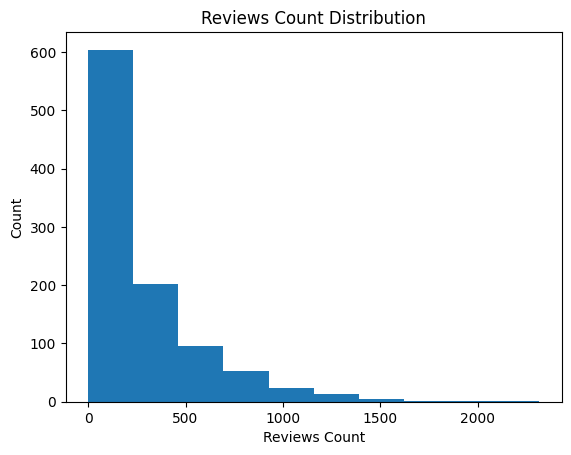

In [9]:
plt.hist(df['reviews_count'])
plt.title("Reviews Count Distribution")
plt.xlabel("Reviews Count")
plt.ylabel("Count")
plt.show()

In [10]:
df["source"].value_counts()

source
amazon        200
noon          200
aliexpress    200
jumia         200
ebay          200
Name: count, dtype: int64

In [11]:
df["source"].value_counts(normalize=True)

source
amazon        0.2
noon          0.2
aliexpress    0.2
jumia         0.2
ebay          0.2
Name: proportion, dtype: float64

In [12]:
df["availability"].value_counts()

availability
in_stock        834
out_of_stock     85
limited          81
Name: count, dtype: int64

In [13]:
df["availability"].value_counts(normalize=True)

availability
in_stock        0.834
out_of_stock    0.085
limited         0.081
Name: proportion, dtype: float64

In [14]:
df["availability"].unique()

array(['in_stock', 'out_of_stock', 'limited'], dtype=object)

In [20]:
in_stock_count=df["availability"].value_counts()["in_stock"]
out_of_stock_count=df["availability"].value_counts()["out_of_stock"]
limited_count=df["availability"].value_counts()["limited"]

values=np.array([in_stock_count, out_of_stock_count, limited_count])
print(in_stock_count)

834


<function matplotlib.pyplot.show(close=None, block=None)>

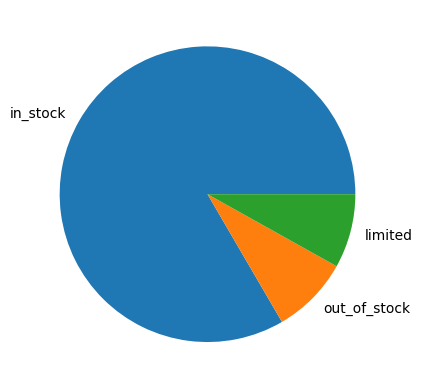

In [23]:
plt.pie(values, labels=["in_stock", "out_of_stock", "limited"])
plt.show

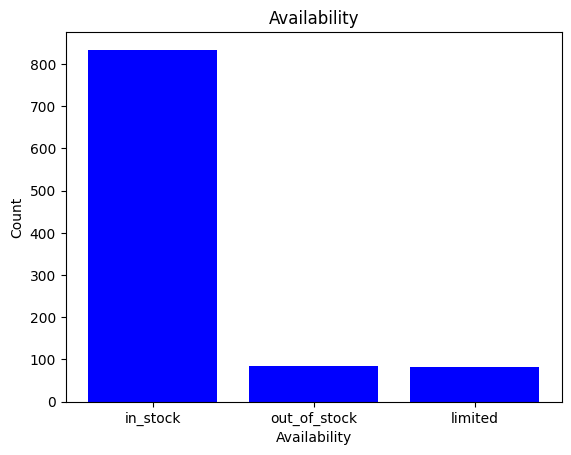

In [24]:
plt.bar(["in_stock", "out_of_stock", "limited"], values, color="blue")
plt.title("Availability")
plt.xlabel("Availability")
plt.ylabel("Count")
plt.show()